In [1]:
from src import *

In [2]:
di_ideal = np.load(r'raw\noisy\di_5px\di_5px_f0.2_d0_raw.npy')
di_noisy = np.load(r'raw\noisy\di_5px\di_5px_f0.2_d42_raw.npy')


pm_ideal = np.load(r'raw\noisy\spade_5px\spade_5px_f0.2_d0_raw.npy')
pm_noisy = np.load(r'raw\noisy\spade_5px\spade_5px_f0.2_d92_raw.npy')

# di_ideal = np.load(r'raw\ideal\di_5px\di_5px_f0.1_d0_raw.npy')
# di_noisy = np.load(r'raw\ideal\di_5px\di_5px_f0.4_d0_raw.npy')


# pm_ideal = np.load(r'raw\ideal\spade_5px\spade_5px_f0.1_d0_raw.npy')
# pm_noisy = np.load(r'raw\ideal\spade_5px\spade_5px_f0.4_d0_raw.npy')

In [3]:
raw = {
    'di_ideal': {'0': qCMOS.convert2photons(di_ideal[0, 0, :-4, :].astype(float), 0),
                '2a': qCMOS.convert2photons(di_ideal[0, 4, :-4, :].astype(float), 0)},

    'di_noisy': {'0': qCMOS.convert2photons(di_noisy[0, 0, :-4, :].astype(float), 0),
                '2a': qCMOS.convert2photons(di_noisy[0, 4, :-4, :].astype(float), 0)},

    'pm_ideal': {'0': qCMOS.convert2photons(pm_ideal[0, 0, :-4, :].astype(float), 0),
                '2a': qCMOS.convert2photons(pm_ideal[0, 4, :-4, :].astype(float), 0)},

    'pm_noisy': {'0': qCMOS.convert2photons(pm_noisy[0, 0, :-4, :].astype(float), 0),
                '2a': qCMOS.convert2photons(pm_noisy[0, 4, :-4, :].astype(float), 0)},
}


limit = {
    'di_ideal': {'vmin': min(raw['di_ideal']['0'].min(), raw['di_ideal']['2a'].min()),
                 'vmax': max(raw['di_ideal']['0'].max(), raw['di_ideal']['2a'].max())},

    'di_noisy': {'vmin': min(raw['di_noisy']['0'].min(), raw['di_noisy']['2a'].min()),
                 'vmax': max(raw['di_noisy']['0'].max(), raw['di_noisy']['2a'].max())},

    'pm_ideal': {'vmin': min(raw['pm_ideal']['0'].min(), raw['pm_ideal']['2a'].min()),
                 'vmax': max(raw['pm_ideal']['0'].max(), raw['pm_ideal']['2a'].max())},

    'pm_noisy': {'vmin': min(raw['pm_noisy']['0'].min(), raw['pm_noisy']['2a'].min()),
                 'vmax': max(raw['pm_noisy']['0'].max(), raw['pm_noisy']['2a'].max())},
}

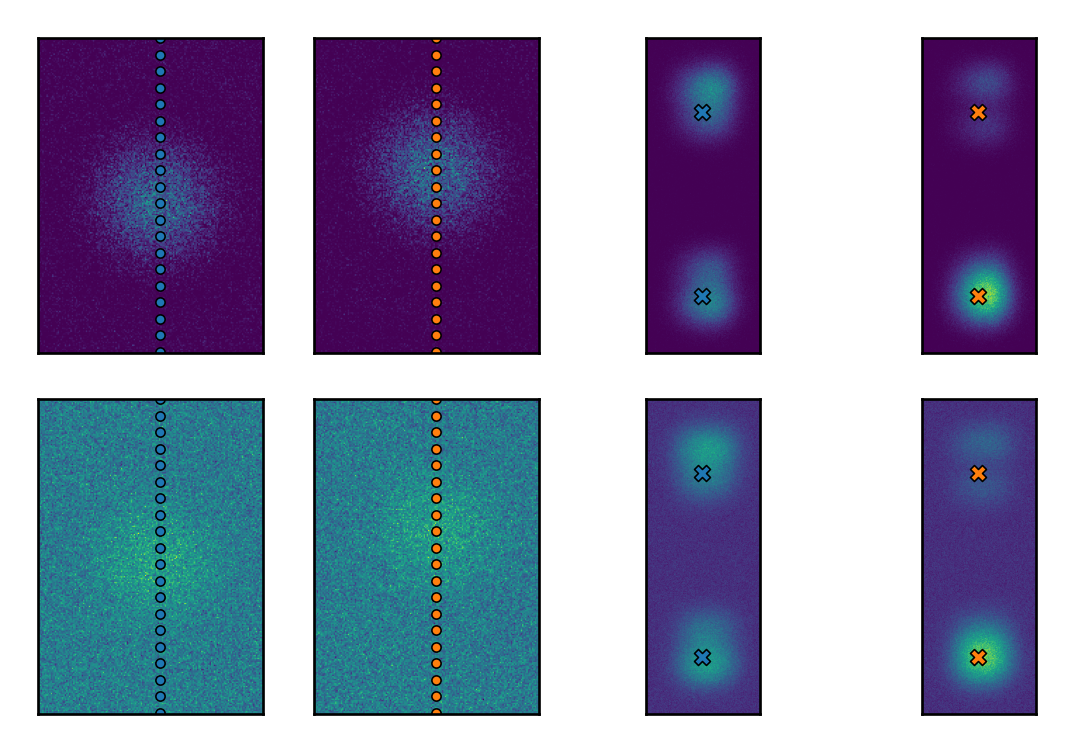

In [49]:
fig, axs = plt.subplots(2, 4, figsize=(3, 2))
axs = np.ravel(axs)

axs[0].imshow(raw['di_ideal']['0'], **limit['di_ideal'])
im1 = axs[1].imshow(raw['di_ideal']['2a'], **limit['di_ideal'])

axs[2].imshow(raw['pm_ideal']['0'], **limit['pm_ideal'])
im2 = axs[3].imshow(raw['pm_ideal']['2a'], **limit['pm_ideal'])

axs[4].imshow(raw['di_noisy']['0'], **limit['di_noisy'])
im3 = axs[5].imshow(raw['di_noisy']['2a'], **limit['di_noisy'])

axs[6].imshow(raw['pm_noisy']['0'], **limit['pm_noisy'])
im4 = axs[7].imshow(raw['pm_noisy']['2a'], **limit['pm_noisy'])

for i in [0, 4]:
    # axs[i].axvline(DI.X_AXIS, color='tab:blue', linestyle='--')
    axs[i].scatter([DI.X_AXIS]*20, np.linspace(0, 223, 20), s=3, color='tab:blue', edgecolor='black', linewidths=0.3)

for i in [1, 5]:
    axs[i].scatter([DI.X_AXIS]*20, np.linspace(0, 223, 20), s=3, color='tab:orange', edgecolor='black', linewidths=0.3)

for i in [2, 6]:
    axs[i].scatter([SPADE.X_AXIS]*2, [SPADE.POINT_1, SPADE.POINT_2], color='tab:blue', marker='X', edgecolors='black', linewidths=0.3)

for i in [3, 7]:
    axs[i].scatter([SPADE.X_AXIS]*2, [SPADE.POINT_1, SPADE.POINT_2], color='tab:orange', marker='X', edgecolors='black', linewidths=0.3)

for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

# fig.colorbar(im1, ax=[axs[0], axs[1]], ticks=np.arange(0, 18, 4))
# fig.colorbar(im2, ax=[axs[2], axs[3]])
# fig.colorbar(im3, ax=[axs[4], axs[5]])
# fig.colorbar(im4, ax=[axs[6], axs[7]])

# axs[0].text(-0.1, 0.5, 'High SNR\n'+r'$(b/\nu\approx 0)$', va='center', ha='right', fontsize=8, transform=axs[0].transAxes)
# axs[4].text(-0.1, 0.5, 'Low SNR\n'+r'$(b/\nu\approx 0.1)$', va='center', ha='right', fontsize=8, transform=axs[4].transAxes)

plt.tight_layout()
plt.savefig('raw.svg')
plt.show()

In [6]:
# di_c = LoadEstimates('data/noisy/di_5px_f0.2_d0.npz')

# binned_1 = qCMOS.convert2photons(di_c.cropped_data[0, 0], 0).reshape(-1, 8).sum(-1)
# binned_2 = qCMOS.convert2photons(di_c.cropped_data[0, 4], 0).reshape(-1, 8).sum(-1)

# plt.bar(np.arange(25), binned_1, alpha=0.6, edgecolor='none', width=0.6, label=r'$0$')
# plt.bar(np.arange(25), binned_2, alpha=0.6, edgecolor='none', width=0.6, label=r'$-2A$')

# # plt.plot(np.arange(200), qCMOS.convert2photons(di_c.cropped_data[0, 0], 0), alpha=0.6, label=r'$0$')
# # plt.plot(np.arange(200), qCMOS.convert2photons(di_c.cropped_data[0, 4], 0), alpha=0.6, label=r'$-2A$')

# # gaus_param = (di_c.time_domain[0, 0] / qCMOS.PIXEL_SIZE + DI.CENTER, DI.SIGMA / qCMOS.PIXEL_SIZE)
# # plt.plot(np.arange(0, 200, 0.1), di_c.photons*norm(*gaus_param).pdf(np.arange(0, 200, 0.1)), color='tab:blue')

# # gaus_param = (di_c.time_domain[0, 4] / qCMOS.PIXEL_SIZE + DI.CENTER, DI.SIGMA / qCMOS.PIXEL_SIZE)
# # plt.plot(np.arange(0, 200, 0.1), di_c.photons*norm(*gaus_param).pdf(np.arange(0, 200, 0.1)), color='tab:orange')

# plt.xticks(np.linspace(0, 25, 6), np.linspace(0, 200, 6).astype(int))
# plt.xlim(0, 25)
# plt.title('Direct imaging (binned)')

# # plt.legend()
# plt.show()

In [7]:
# def binning(c):
#     binned_1 = qCMOS.convert2photons(c.cropped_data[0, 0], 0).reshape(-1, 8).sum(-1)
#     binned_2 = qCMOS.convert2photons(c.cropped_data[0, 4], 0).reshape(-1, 8).sum(-1)

#     return binned_1, binned_2

In [8]:
# fig, axes = plt.subplots(2, 1, figsize=(8.5 / 2.54, 2*0.618 * 8.5 / 2.54), sharex=True)


# binned_1, binned_2 = binning(LoadEstimates('data/noisy/di_5px_f0.2_d0.npz'))
# binned_3, binned_4 = binning(LoadEstimates('data/noisy/di_5px_f0.2_d92.npz'))

# axes[0].bar(np.arange(25)+0.5, binned_1, alpha=0.6, edgecolor='none', width=0.6, label=r'$0$')
# axes[0].bar(np.arange(25)+0.5, binned_2, alpha=0.6, edgecolor='none', width=0.6, label=r'$-2A$')

# axes[1].bar(np.arange(25)+0.5, binned_3, alpha=0.6, edgecolor='none', width=0.6, label=r'$0$')
# axes[1].bar(np.arange(25)+0.5, binned_4, alpha=0.6, edgecolor='none', width=0.6, label=r'$-2A$')


# for ax in axes.ravel():
#     ax.set_box_aspect(0.618)
#     ax.set_xlim(0, 25)
#     ax.set_xticks(np.linspace(0, 25, 6), np.linspace(0, 200, 6).astype(int))

# axes[1].set_xlabel('Pixel (binned)')
# axes[0].set_ylabel('Photons (binned)')
# axes[1].set_ylabel('Photons (binned)')

# plt.tight_layout()
# plt.savefig('di_hist.svg')
# plt.show()

In [9]:
# spade_c1 = LoadEstimates('data/noisy/spade_5px_f0.2_d0.npz')
# spade_c2 = LoadEstimates('data/noisy/spade_5px_f0.2_d92.npz')

In [10]:
# fig, axs = plt.subplots(2, 1, figsize=(8.5 / 2.54, 2*0.618 * 8.5 / 2.54), sharex=True)

# width = 0.18

# y1 = qCMOS.convert2photons(spade_c1.cropped_data[0, 0], 0)
# y2 = qCMOS.convert2photons(spade_c1.cropped_data[0, 4], 0)

# axs[0].bar([0], y1[0], width=width, alpha=0.6, color='tab:blue', label=r'$0$')
# axs[0].bar([0.02+width], y2[0], width=width, alpha=0.6, color='tab:orange', label=r'$-2A$')

# axs[0].bar([1 - 0.2], y1[1], width=width, alpha=0.6, color='tab:blue')
# axs[0].bar([1.02+width - 0.2], y2[1], width=width, alpha=0.6, color='tab:orange')


# y1 = qCMOS.convert2photons(spade_c2.cropped_data[0, 0], 0)
# y2 = qCMOS.convert2photons(spade_c2.cropped_data[0, 4], 0)

# axs[1].bar([0], y1[0], width=width, alpha=0.6, color='tab:blue', label=r'$0$')
# axs[1].bar([0.02+width], y2[0], width=width, alpha=0.6, color='tab:orange', label=r'$-2A$')

# axs[1].bar([1 - 0.2], y1[1], width=width, alpha=0.6, color='tab:blue')
# axs[1].bar([1.02+width - 0.2], y2[1], width=width, alpha=0.6, color='tab:orange')

# axs[0].set_xticks([0.1, 1.1 - 0.2], [r'$\phi_+$', r'$\phi_-$'])
# axs[1].set_xticks([0.1, 1.1 - 0.2], [r'$\phi_+$', r'$\phi_-$'])

# axs[0].legend(frameon=False)
# axs[0].tick_params(axis='x', which='minor', bottom=False, top=False)
# axs[1].tick_params(axis='x', which='minor', bottom=False, top=False)

# axs[1].set_xlabel('Mode')
# axs[0].set_ylabel('Photons')
# axs[1].set_ylabel('Photons')

# axs[0].set_box_aspect(0.618)
# axs[1].set_box_aspect(0.618)

# plt.tight_layout()
# plt.savefig('pm_spade_hist.svg')
# plt.show()

In [10]:
def plot_data():
    def binning(c):
        binned_1 = qCMOS.convert2photons(c.cropped_data[0, 0], 0).reshape(-1, 8).sum(-1)
        binned_2 = qCMOS.convert2photons(c.cropped_data[0, 4], 0).reshape(-1, 8).sum(-1)

        return binned_1, binned_2

    binned_1, binned_2 = binning(LoadEstimates('data/noisy/di_5px_f0.2_d0.npz'))
    binned_3, binned_4 = binning(LoadEstimates('data/noisy/di_5px_f0.2_d92.npz'))


    width = 0.18
    spade_c1 = LoadEstimates('data/noisy/spade_5px_f0.2_d0.npz')
    spade_c2 = LoadEstimates('data/noisy/spade_5px_f0.2_d92.npz')

    y1 = qCMOS.convert2photons(spade_c1.cropped_data[0, 0], 0)
    y2 = qCMOS.convert2photons(spade_c1.cropped_data[0, 4], 0)

    y3 = qCMOS.convert2photons(spade_c2.cropped_data[0, 0], 0)
    y4 = qCMOS.convert2photons(spade_c2.cropped_data[0, 4], 0)

    _plot_data = [
        [np.arange(25)+0.5, binned_1], [np.arange(25)+0.5, binned_2],  # ax[0, 0]
        [np.arange(25)+0.5, binned_3], [np.arange(25)+0.5, binned_4],  # ax[1, 0]

        [[0, (1 - 0.2)], [y1[0], y1[1]]], [[(0.02+width), (1.02+width - 0.2)], [y2[0], y2[1]]],  # ax[0, 1]
        [[0, (1 - 0.2)], [y3[0], y3[1]]], [[(0.02+width), (1.02+width - 0.2)], [y4[0], y4[1]]]   # ax[1, 1]
    ]

    return _plot_data

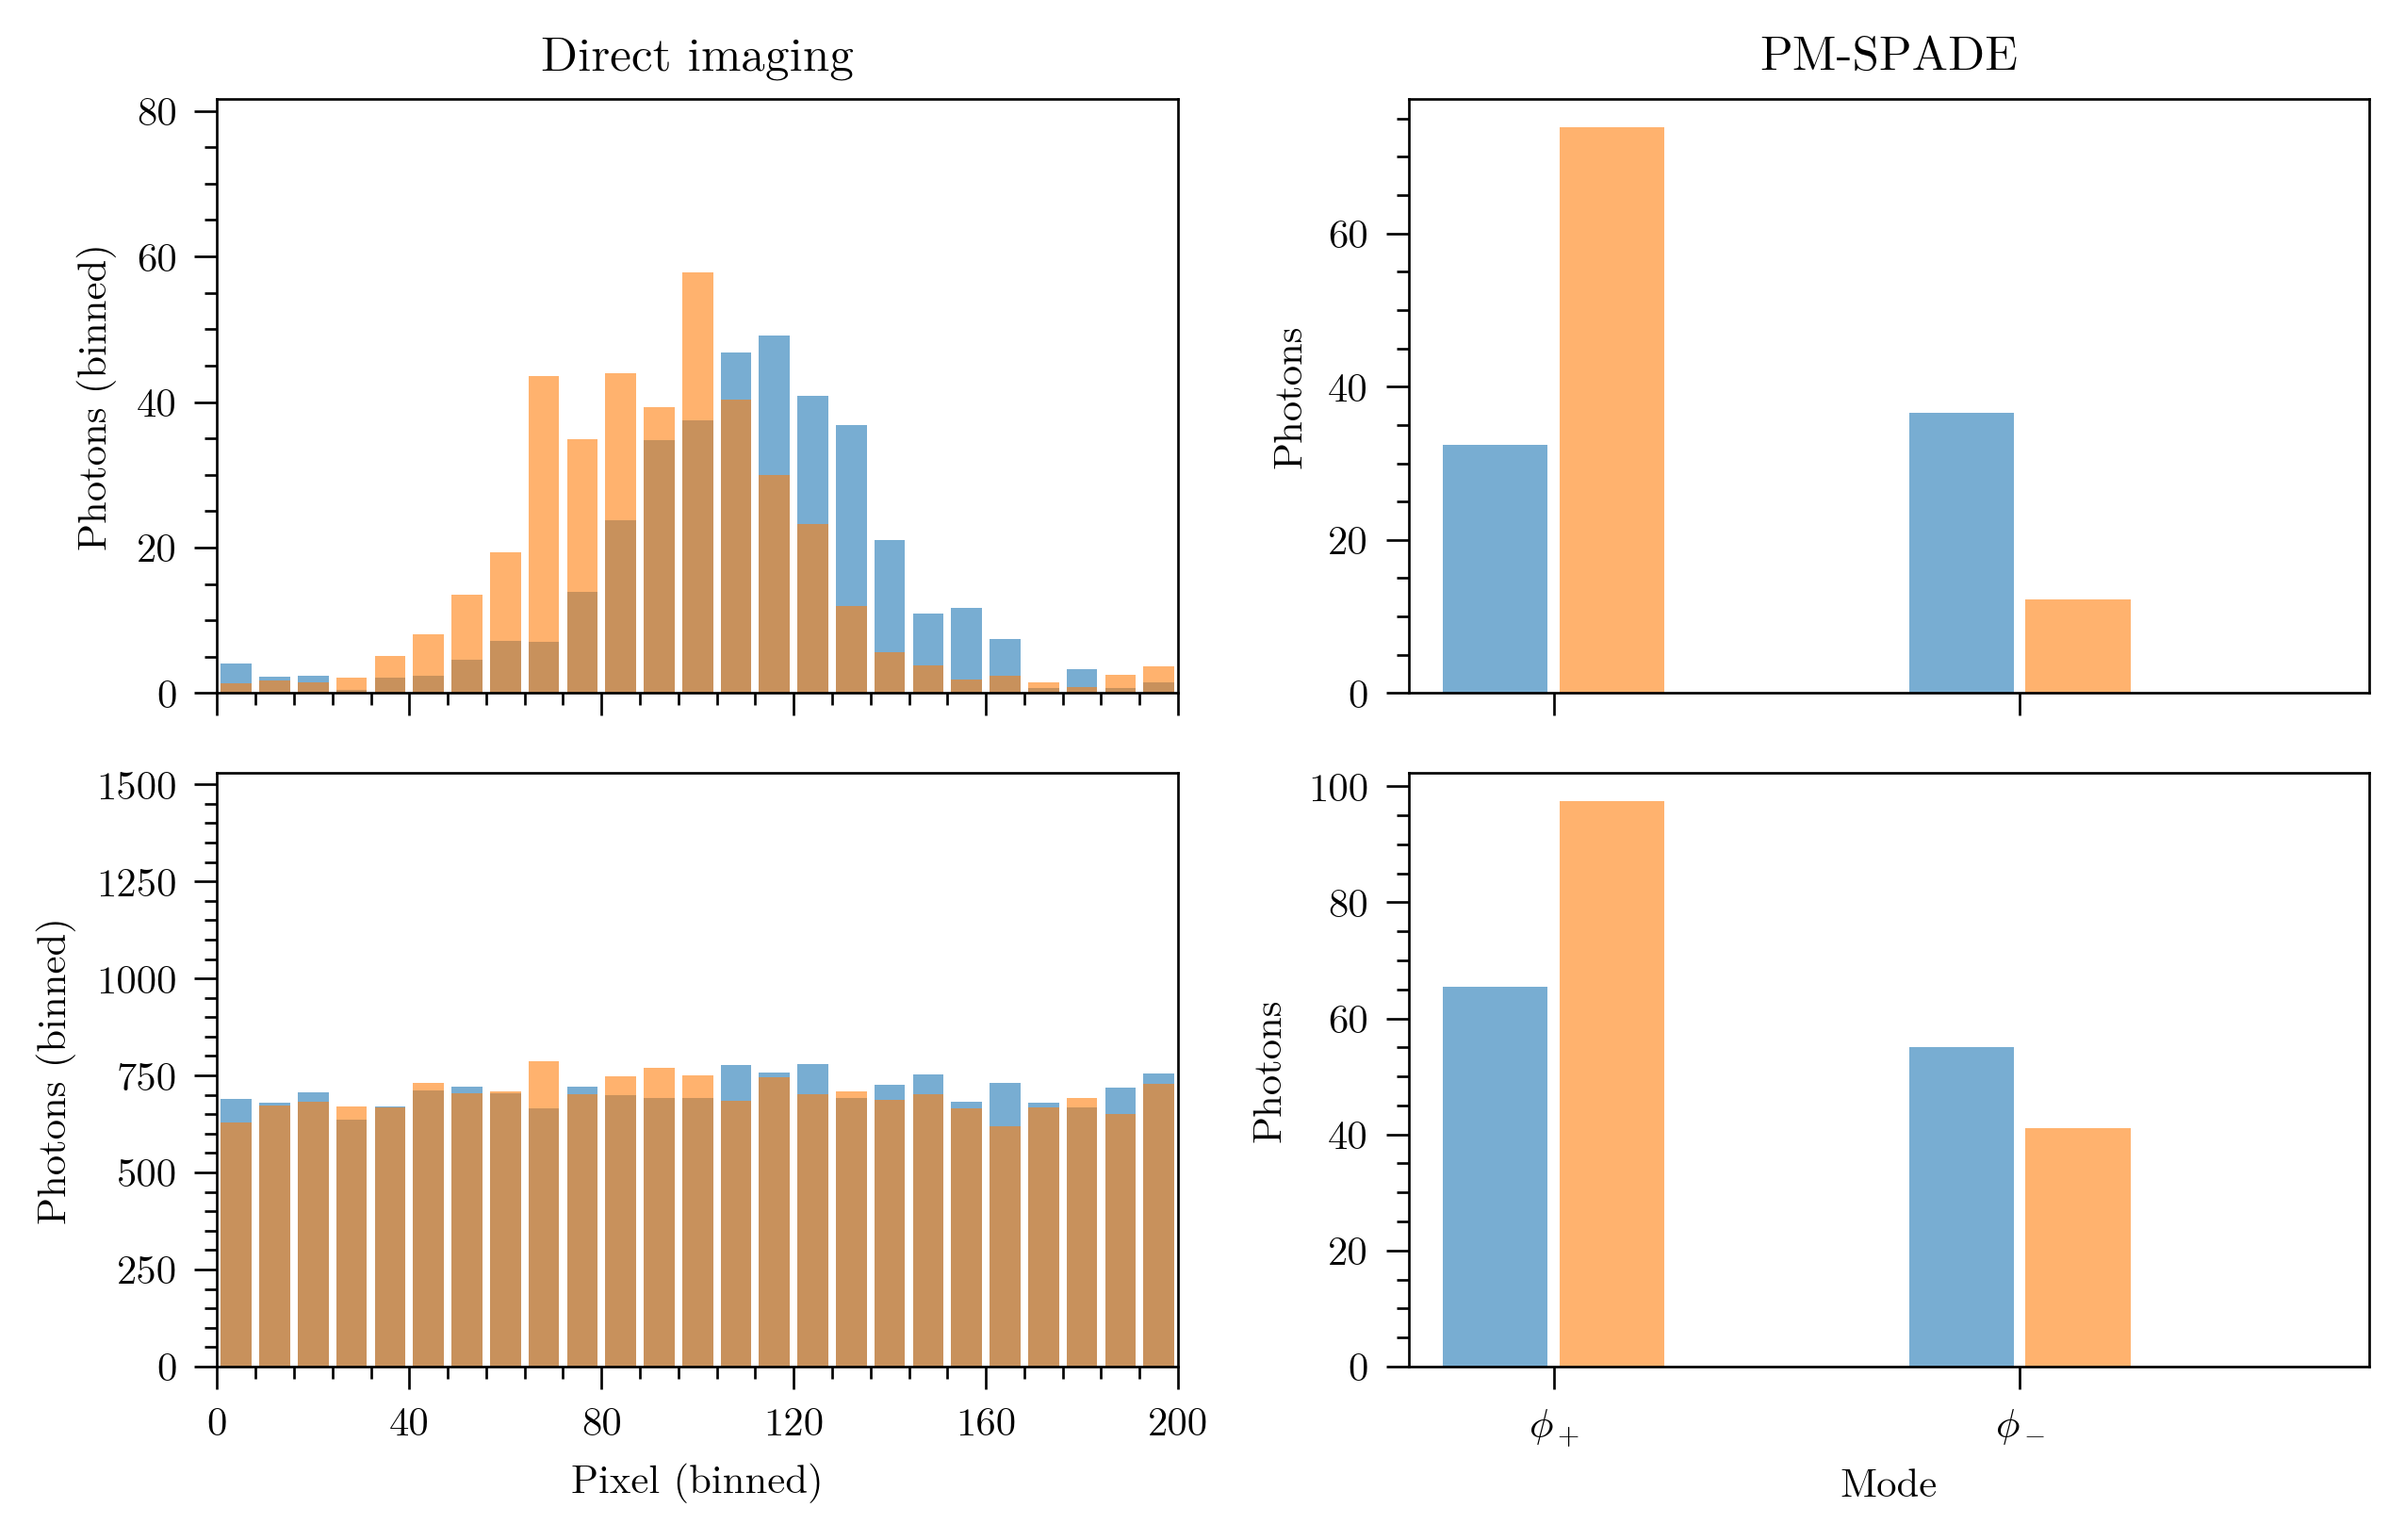

In [69]:
fig, axes = plt.subplots(2, 2, figsize=(17/2.54, 0.65 * 17/2.54), sharex='col')

data = plot_data()
for i, ax in enumerate(axes.ravel()):
    ax.set_box_aspect(0.618)

axes[0, 0].bar(*data[0], alpha=0.6)
axes[0, 0].bar(*data[1], alpha=0.6)

axes[1, 0].bar(*data[2], alpha=0.6)
axes[1, 0].bar(*data[3], alpha=0.6)

axes[0, 1].bar(*data[4], width=0.18, alpha=0.6)
axes[0, 1].bar(*data[5], width=0.18, alpha=0.6)

axes[1, 1].bar(*data[6], width=0.18, alpha=0.6)
axes[1, 1].bar(*data[7], width=0.18, alpha=0.6)

axes[0, 0].set_title('Direct imaging')
axes[0, 1].set_title('PM-SPADE')

axes[0, 0].set_ylabel('Photons (binned)')
axes[1, 0].set_ylabel('Photons (binned)')

axes[0, 1].tick_params(axis='x', which='minor', bottom=False, top=False)
axes[1, 1].tick_params(axis='x', which='minor', bottom=False, top=False)

axes[0, 0].set_xticks(np.linspace(0, 25, 6), np.linspace(0, 200, 6).astype(int))
axes[1, 0].set_xticks(np.linspace(0, 25, 6), np.linspace(0, 200, 6).astype(int))

axes[0, 0].set_xlim(0, 25)
axes[1, 0].set_xlim(0, 25)

axes[0, 0].set_ylim(0, 80*1.02)
axes[1, 0].set_ylim(0, 1500*1.02)
axes[0, 1].set_xlim(None, 1.5)

axes[1, 0].set_xlabel('Pixel (binned)')
axes[1, 1].set_xlabel('Mode')
axes[0, 1].set_ylabel('Photons')
axes[1, 1].set_ylabel('Photons')
axes[0, 1].set_xticks([0.1, 1.1 - 0.2], [r'$\phi_+$', r'$\phi_-$'])
axes[1, 1].set_xticks([0.1, 1.1 - 0.2], [r'$\phi_+$', r'$\phi_-$'])

plt.savefig('hist.svg')
plt.tight_layout()
plt.show()